# Coste de la política: margen perdido vs capital inmovilizado

La notebook 05 mide la decisión en **unidades**. Esta la valora en **dinero**: una unidad no servida de un SKU caro y una unidad parada de uno barato no pesan igual.

Supuestos (el dataset trae precio de venta, no coste de compra):

| Parámetro | Valor | Qué representa |
|-----------|------:|----------------|
| Margen bruto | 40% del precio | Lo que se deja de ganar por cada unidad no servida |
| Tasa de posesión | 25% del coste / año | Capital, almacén y merma de tener una unidad parada |

Sobre el mismo holdout de 30 días se barre un grid de z y se elige el que minimiza `margen perdido + coste de posesión`.

> Requiere el paquete instalable: `pip install -e .` desde la raíz del repo.

In [1]:
import pandas as pd

from inventario_ecommerce import config
from inventario_ecommerce.dataset import load_transactions, save_processed
from inventario_ecommerce.features import (
    clean_transactions,
    compute_abc_classification,
    prepare_daily_demand,
    sales_by_product_last_quarter,
)
from inventario_ecommerce.modeling.economics import (
    attach_costs,
    cost_by_policy,
    cost_sensitivity,
    optimal_z,
    optimal_z_by_class,
    unit_prices_by_sku,
    z_grid_policies,
)
from inventario_ecommerce.modeling.simulate import simulate_policies
from inventario_ecommerce.plots import plot_cost_vs_service

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Margen bruto:", f"{config.GROSS_MARGIN_RATE:.0%}")
print("Tasa de posesión anual:", f"{config.ANNUAL_HOLDING_RATE:.0%}")
print("Grid de z:", config.SERVICE_Z_GRID)

Margen bruto: 40%
Tasa de posesión anual: 25%
Grid de z: (0.0, 0.25, 0.5, 0.75, 1.0, 1.28, 1.5, 1.65, 1.88, 2.0, 2.33, 2.5, 3.0)


## 1. Precio por SKU y barrido de z

El precio unitario es la mediana de las líneas del último trimestre. Mediana y no media: el mismo SKU se vende a precios distintos y algunas líneas llevan promociones extremas.

In [2]:
raw = load_transactions()
clean = clean_transactions(raw)
abc = compute_abc_classification(sales_by_product_last_quarter(clean))
daily = prepare_daily_demand(clean, abc=abc)
prices = unit_prices_by_sku(clean)

policies = z_grid_policies()
z_by_policy = {p.name: float(p.z) for p in policies}
by_sku, _ = simulate_policies(daily, abc, policies=policies)

costed = attach_costs(by_sku, prices)
costs = cost_by_policy(costed).assign(z=lambda d: d["policy"].map(z_by_policy))
costs = costs.sort_values("z").reset_index(drop=True)

print(f"SKUs con precio: {prices[config.COL_STOCK_CODE].nunique():,}")
print(f"Precio mediano del catálogo: {prices['unit_price'].median():.2f}")
costs[["z", "fill_rate", "stockout_cost", "holding_cost", "total_cost"]]

Simulada política z_0.00 sobre 2,943 SKUs


Simulada política z_0.25 sobre 2,943 SKUs


Simulada política z_0.50 sobre 2,943 SKUs


Simulada política z_0.75 sobre 2,943 SKUs


Simulada política z_1.00 sobre 2,943 SKUs


...

Simulada política z_2.33 sobre 2,943 SKUs


Simulada política z_2.50 sobre 2,943 SKUs


Simulada política z_3.00 sobre 2,943 SKUs


SKUs con precio: 3,228
Precio mediano del catálogo: 2.08


,z,fill_rate,stockout_cost,holding_cost,total_cost
0,0.00,0.73,"149,091.26","4,990.18","154,081.44"
1,0.25,0.76,"134,509.62","5,643.91","140,153.53"
2,0.50,0.78,"121,879.03","6,323.27","128,202.30"
3,0.75,0.81,"110,853.51","7,013.04","117,866.55"
4,1.00,0.82,"100,841.07","7,720.11","108,561.18"
5,1.28,0.84,"90,729.26","8,527.38","99,256.64"
6,1.50,0.86,"83,462.59","9,172.00","92,634.60"
7,1.65,0.87,"78,947.06","9,616.68","88,563.74"
8,1.88,0.88,"72,686.45","10,306.53","82,992.98"
9,2.00,0.88,"69,727.09","10,670.08","80,397.16"


## 2. Dónde se cruza el margen perdido con el capital inmovilizado

Sobre 30 días, tener una unidad parada cuesta ~2% de su coste (25% anual × 30/365). Dejar de venderla cuesta el 40% del precio. Por eso el coste de quiebre domina la curva hasta bien arriba del grid.

z de coste mínimo: 3.00 (fill rate 91.6%)
Coste en z = 1.88 (política anterior): 82,993
Coste en z óptimo (= producción):     64,726
Ahorro potencial en el holdout:       18,267


WindowsPath('C:/code/proyecto-a-inventario-ecommerce/reports/figures/policy_cost_vs_service.png')

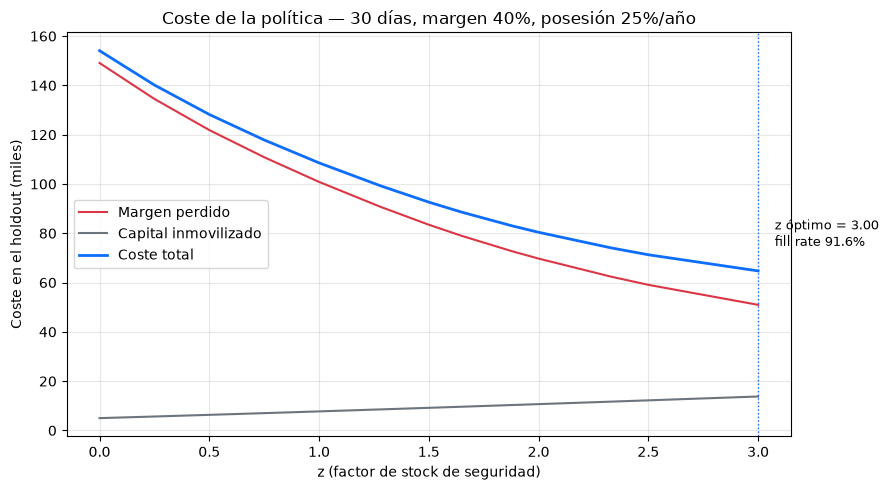

In [3]:
best = costs.loc[costs["total_cost"].idxmin()]
anterior = costs.loc[costs["z"] == 1.88].iloc[0]

print(f"z de coste mínimo: {best['z']:.2f} (fill rate {best['fill_rate']:.1%})")
print(f"Coste en z = 1.88 (política anterior): {anterior['total_cost']:,.0f}")
print(f"Coste en z óptimo (= producción):     {best['total_cost']:,.0f}")
print(f"Ahorro potencial en el holdout:       {anterior['total_cost'] - best['total_cost']:,.0f}")

plot_cost_vs_service(costs, save=True)

## 3. ¿Cambia el óptimo por clase ABC?

Si la relación margen/posesión fuera distinta entre clases, cada una tendría su propio z. Aquí se calcula por separado.

In [4]:
by_class = optimal_z_by_class(costed, z_by_policy)
by_class

,ABCClass,z,stockout_cost,holding_cost,total_cost,fill_rate
0,A,3.00,"24,292.92","9,445.76","33,738.68",0.95
1,B,3.00,"17,250.28","2,904.75","20,155.03",0.87
2,C,3.00,"9,417.51","1,415.10","10,832.61",0.79


## 4. Sensibilidad: cuándo deja de compensar cubrirse

El resultado anterior depende de los supuestos. Se revalora la misma simulación bajo márgenes del 5% al 60% y tasas de posesión del 15% al 100% (esta última sería moda o producto con alta obsolescencia).

In [5]:
sensitivity = cost_sensitivity(by_sku, prices, z_by_policy)
sensitivity.pivot(index="margin_rate", columns="annual_holding_rate", values="z_optimo")

annual_holding_rate,0.15,0.25,0.50,1.00
margin_rate,,,,
0.05,2.00,1.00,0.00,0.00
0.10,3.00,2.50,1.28,0.00
0.20,3.00,3.00,2.50,1.50
0.40,3.00,3.00,3.00,3.00
0.60,3.00,3.00,3.00,3.00


## 5. Artefactos

In [6]:
save_processed(costs, "policy_cost_by_z.csv")
save_processed(by_class, "policy_cost_optimal_by_class.csv")
save_processed(sensitivity, "policy_cost_sensitivity.csv")

print("Carpeta:", config.PROCESSED_DATA_DIR)

Carpeta: C:\code\proyecto-a-inventario-ecommerce\data\processed


## Lectura

- **Con margen 40% y posesión 25%, el coste mínimo está en el techo del grid (z = 3.0).** Sobre 30 días, inmovilizar una unidad cuesta ~2% de su coste; no servirla cuesta el 40% del precio. El quiebre pesa mucho más.
- **Pasar de z = 1.88 (política anterior) a z = 3.0 ahorra ~18k en el holdout** (~83k → ~65k). El fill rate sube del 88% al 92%.
- **Las tres clases ABC eligen el mismo z = 3.0.** Diferenciar el factor de seguridad por clase no se justifica en coste bajo estos supuestos: lo que separa A de C es el volumen, no la relación margen/posesión. **`predict` ya usa z = 3.0 en las tres clases.**
- **Solo con márgenes muy finos (≤10%) y alta obsolescencia (≥50%/año) el óptimo baja.** En el extremo (5% de margen, 100% de posesión anual) conviene z = 0: no pagar stock de seguridad.
- **El techo del 92% no se rompe subiendo z.** Es el mismo límite que apareció en la notebook 05: el holdout es la subida de Navidad y con 14 días de lead time el forecast va por detrás. Más stock de seguridad mitiga, no arregla, un nivel que se queda corto.